In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
x = pd.read_csv('indian_engineering_student_placement.csv', index_col='Student_ID')

In [3]:
y = pd.read_csv('placement_targets.csv' ,index_col = 'Student_ID')

In [4]:
x.head()

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
Student_ID,,,,,,,,,,,,,,,,,,,,,
1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [5]:
y.head()

,placement_status,salary_lpa
Student_ID,,
1,Placed,14.95
2,Placed,14.91
3,Placed,17.73
4,Placed,14.52
5,Placed,15.91


In [6]:
len(x)

5000

In [7]:
len(y)

5000

In [8]:
# dual dataset, requires both classification and regression

In [9]:
# splitting labels into 2

In [10]:
y_class = y['placement_status']

In [11]:
y_reg = y['salary_lpa']

In [12]:
y_class[20:40]

Student_ID
21    Not Placed
22    Not Placed
23        Placed
24        Placed
25        Placed
26    Not Placed
27        Placed
28        Placed
29        Placed
30        Placed
31        Placed
32        Placed
33        Placed
34        Placed
35        Placed
36        Placed
37        Placed
38        Placed
39        Placed
40        Placed
Name: placement_status, dtype: object

In [13]:
y_reg.head()

Student_ID
1    14.95
2    14.91
3    17.73
4    14.52
5    15.91
Name: salary_lpa, dtype: float64

In [14]:
from sklearn.preprocessing import LabelBinarizer

In [15]:
label_encoder = LabelBinarizer()

In [16]:
coded_y_class=label_encoder.fit_transform(y_class)

In [17]:
coded_y_class[20:40]

array([[0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1]])

In [18]:
y_reg.notna().sum() # no NA values

np.int64(5000)

In [604]:
joblib.dump(label_encoder, 'project_1_encoder.pkl')

['project_1_encoder.pkl']

<Axes: >

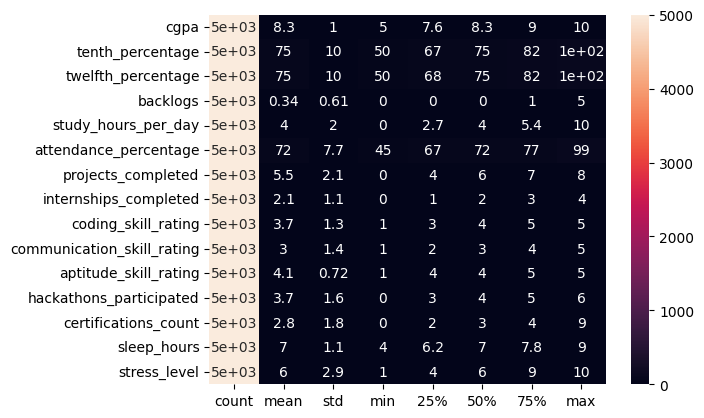

In [19]:
sns.heatmap(x.describe().transpose(), annot=True)

In [20]:
x.dtypes

gender                          object
branch                          object
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                   object
family_income_level             object
city_tier                       object
internet_access                 object
extracurricular_involvement     object
dtype: object

In [21]:
# we will have to convert all of these 'objects' to float or int before we visualize 

<Axes: >

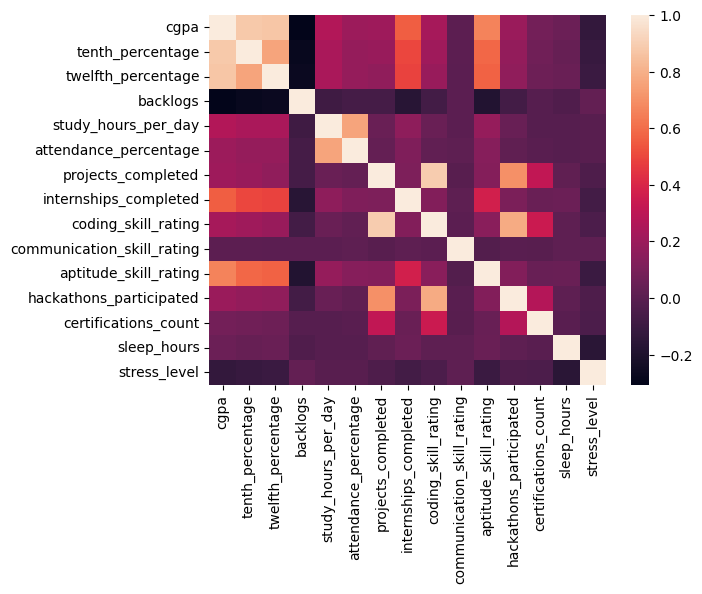

In [22]:
sns.heatmap(x.corr(numeric_only=True))

In [23]:
#let us tackle gender first , then see if it relates as well

In [24]:
x.tail()

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
Student_ID,,,,,,,,,,,,,,,,,,,,,
4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,3,...,5,4,2,7.3,2,No,Medium,Tier 3,Yes,Low
4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,4,...,4,3,2,7.8,6,No,Low,Tier 1,Yes,Low
4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,1,...,4,6,2,6.1,5,Yes,Low,Tier 2,No,Medium
4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,4,...,4,4,5,9.0,10,No,Medium,Tier 2,Yes,High
5000,Male,CSE,9.45,85.6,80.0,0,2.8,63.4,8,4,...,4,6,2,7.8,1,No,Low,Tier 1,No,High


In [25]:
genders= pd.get_dummies(x['gender'],dtype = 'int32')

In [26]:
x = pd.concat([x,genders], axis=1)

In [27]:
x.head(20)

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,Female,Male
Student_ID,,,,,,,,,,,,,,,,,,,,,
1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,0,1
2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,1,0
3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,3,6.1,2,No,Low,Tier 2,Yes,High,1,0
4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,0,1
5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,0,1
6,Male,CSE,7.46,70.5,70.4,3,3.6,81.7,5,3,...,2,8.8,10,Yes,High,Tier 1,Yes,Medium,0,1
7,Male,CE,8.26,81.2,74.8,0,1.8,59.6,4,1,...,4,5.7,8,No,Low,Tier 1,No,High,0,1
8,Female,IT,7.01,63.9,61.2,0,2.4,64.7,7,1,...,5,4.2,10,No,Medium,Tier 2,Yes,Low,1,0
9,Female,CSE,7.97,71.4,73.8,1,7.6,75.5,7,2,...,7,5.4,10,No,Medium,Tier 2,Yes,Medium,1,0


In [28]:
x = x.drop('gender', axis=1)

In [29]:
#does not seem to be very related to any metric

In [30]:
x.dtypes

branch                          object
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                   object
family_income_level             object
city_tier                       object
internet_access                 object
extracurricular_involvement     object
Female                           int32
Male                             int32
dtype: object

In [31]:
# checking branch next

In [32]:
x['branch'].unique()

array(['ECE', 'IT', 'CSE', 'CE', 'ME'], dtype=object)

In [33]:
count_branch=x['branch'].value_counts()
count_branch

branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64

In [34]:
#heavily skewed towards cse
#first we encode them

<Axes: xlabel='branch', ylabel='count'>

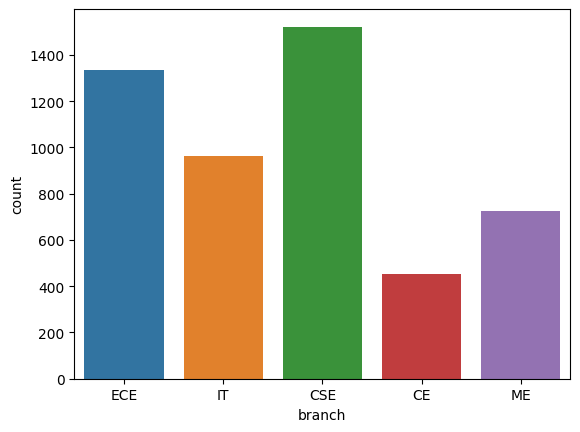

In [35]:
sns.countplot(data = x,x='branch', hue='branch')

<Axes: xlabel='branch', ylabel='count'>

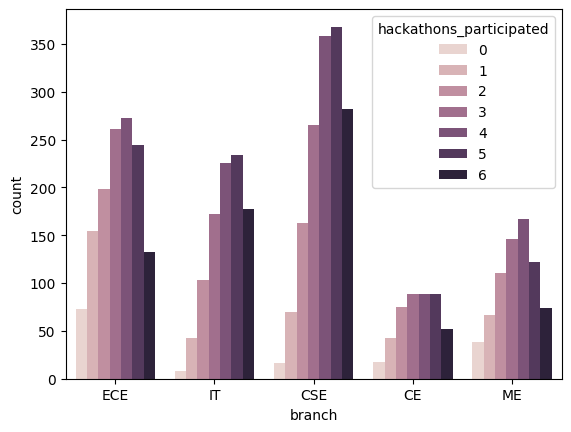

In [36]:
sns.countplot(data = x,x='branch', hue='hackathons_participated')

In [37]:
branch_labels = {
    'CSE':0,
    'IT':1,
    'ECE':2,
    'CE':3,
    'ME':4
}
x['branch']= x['branch'].replace(branch_labels)    

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\3377500754.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['branch']= x['branch'].replace(branch_labels)


In [132]:
x['branch'][:10]

Student_ID
1     2
2     2
3     1
4     2
5     1
6     0
7     3
8     1
9     0
10    2
Name: branch, dtype: int64

In [133]:
x['branch'][5000]

np.int64(0)

In [39]:
x.dtypes

branch                           int64
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                   object
family_income_level             object
city_tier                       object
internet_access                 object
extracurricular_involvement     object
Female                           int32
Male                             int32
dtype: object

In [40]:
x['part_time_job']

Student_ID
1       Yes
2       Yes
3        No
4        No
5        No
       ... 
4996     No
4997     No
4998    Yes
4999     No
5000     No
Name: part_time_job, Length: 5000, dtype: object

In [41]:
part_time_labels = {'Yes': 1,
                   'No': 0}

x['part_time_job']=x['part_time_job'].replace(part_time_labels)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\1723443545.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['part_time_job']=x['part_time_job'].replace(part_time_labels)


In [42]:
x['part_time_job'][5000]

np.int64(0)

In [43]:
x.dtypes

branch                           int64
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                    int64
family_income_level             object
city_tier                       object
internet_access                 object
extracurricular_involvement     object
Female                           int32
Male                             int32
dtype: object

In [44]:
x['family_income_level'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [45]:
family_income_labels = {
    'Medium':1,
    'Low':0,
    'High':2
}

x['family_income_level'] = x['family_income_level'].replace(family_income_labels)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\4141787714.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['family_income_level'] = x['family_income_level'].replace(family_income_labels)


In [46]:
x['family_income_level']

Student_ID
1       1
2       1
3       0
4       1
5       1
       ..
4996    1
4997    0
4998    0
4999    1
5000    0
Name: family_income_level, Length: 5000, dtype: int64

In [47]:
x['city_tier'].unique()

array(['Tier 2', 'Tier 3', 'Tier 1'], dtype=object)

In [48]:
city_tier_labels ={
    'Tier 1':1,
    'Tier 2':2,
    'Tier 3':3
}

x['city_tier'] = x['city_tier'].replace(city_tier_labels)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\4201629530.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['city_tier'] = x['city_tier'].replace(city_tier_labels)


In [49]:
x['city_tier']

Student_ID
1       2
2       3
3       2
4       1
5       1
       ..
4996    3
4997    1
4998    2
4999    2
5000    1
Name: city_tier, Length: 5000, dtype: int64

In [50]:
x['internet_access'].unique()

array(['Yes', 'No'], dtype=object)

In [51]:
internet_encoder = {
    'Yes':1,
    'No':2
}

x['internet_access'] = x['internet_access'].replace(internet_encoder)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\882984244.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['internet_access'] = x['internet_access'].replace(internet_encoder)


In [52]:
x['internet_access']

Student_ID
1       1
2       1
3       1
4       1
5       1
       ..
4996    1
4997    1
4998    2
4999    1
5000    2
Name: internet_access, Length: 5000, dtype: int64

In [53]:
x['extracurricular_involvement'].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [54]:
x['extracurricular_involvement'].isna().sum()

np.int64(1006)

In [55]:
x['extracurricular_involvement']=x['extracurricular_involvement'].fillna('none')

In [56]:
x['extracurricular_involvement'].unique()

array(['Medium', 'Low', 'High', 'none'], dtype=object)

In [57]:
extra_encoder = {
    'none': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3,
}

x['extracurricular_involvement']=x['extracurricular_involvement'].replace(extra_encoder)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\679225064.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['extracurricular_involvement']=x['extracurricular_involvement'].replace(extra_encoder)


In [58]:
x['extracurricular_involvement']

Student_ID
1       2
2       1
3       3
4       1
5       2
       ..
4996    1
4997    1
4998    2
4999    3
5000    3
Name: extracurricular_involvement, Length: 5000, dtype: int64

In [59]:
x.dtypes

branch                           int64
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                    int64
family_income_level              int64
city_tier                        int64
internet_access                  int64
extracurricular_involvement      int64
Female                           int32
Male                             int32
dtype: object

<Axes: >

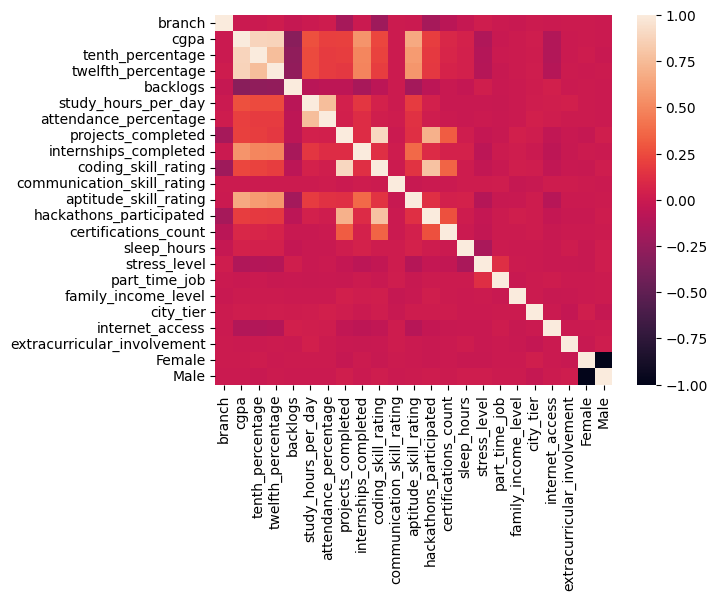

In [60]:
sns.heatmap(x.corr())

In [61]:
# beginning proper EDA

In [62]:
#lets begin with cgpa

In [63]:
x.corr()['cgpa'].sort_values(ascending=False)

cgpa                           1.000000
tenth_percentage               0.880473
twelfth_percentage             0.872270
aptitude_skill_rating          0.661614
internships_completed          0.558580
study_hours_per_day            0.268219
coding_skill_rating            0.232225
projects_completed             0.205021
attendance_percentage          0.202225
hackathons_participated        0.195218
certifications_count           0.079264
sleep_hours                    0.054210
city_tier                      0.016515
communication_skill_rating     0.006288
Female                         0.004368
family_income_level            0.001401
extracurricular_involvement   -0.002405
Male                          -0.004368
branch                        -0.004856
part_time_job                 -0.013912
internet_access               -0.120907
stress_level                  -0.127415
backlogs                      -0.305875
Name: cgpa, dtype: float64

<Axes: xlabel='cgpa', ylabel='tenth_percentage'>

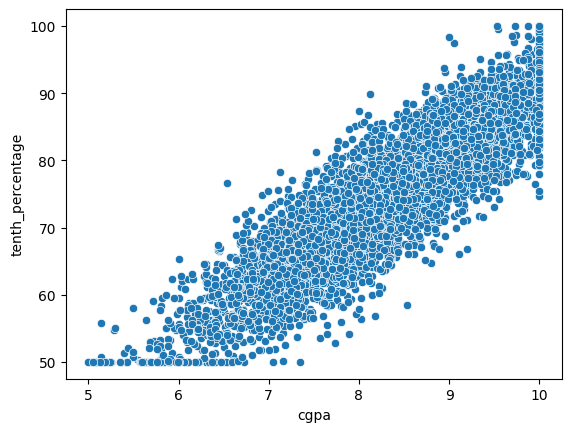

In [64]:
#10 th percentage

sns.scatterplot(data=x, x='cgpa', y='tenth_percentage')

<Axes: xlabel='cgpa', ylabel='twelfth_percentage'>

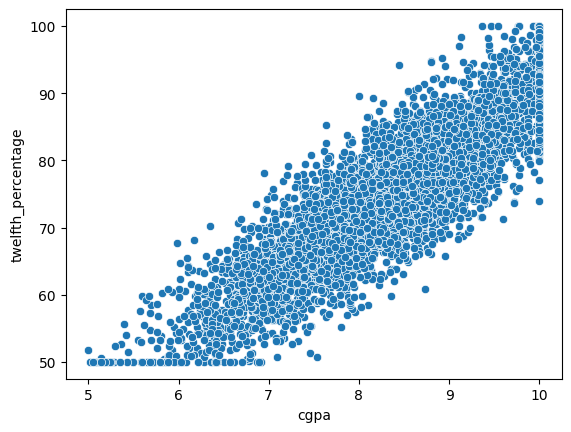

In [65]:
#twelfth percent

sns.scatterplot(data=x, x='cgpa', y='twelfth_percentage')

<Axes: xlabel='cgpa', ylabel='aptitude_skill_rating'>

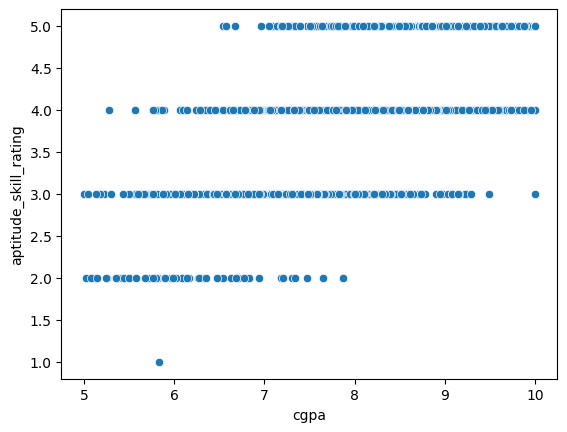

In [66]:
sns.scatterplot(data = x, x ='cgpa', y='aptitude_skill_rating')

<Axes: xlabel='internships_completed', ylabel='count'>

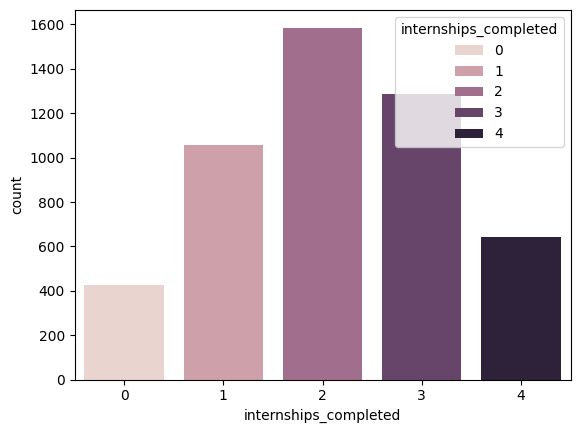

In [67]:
sns.countplot(data = x, x = 'internships_completed', hue ='internships_completed')

<Axes: xlabel='cgpa', ylabel='Male'>

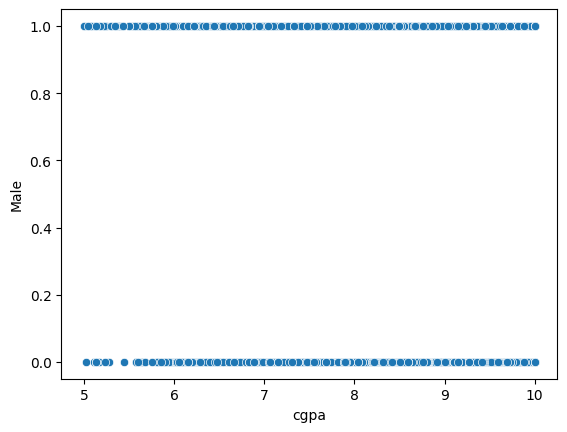

In [68]:
sns.scatterplot(data=x, x='cgpa', y='Male')

<Axes: xlabel='cgpa', ylabel='Female'>

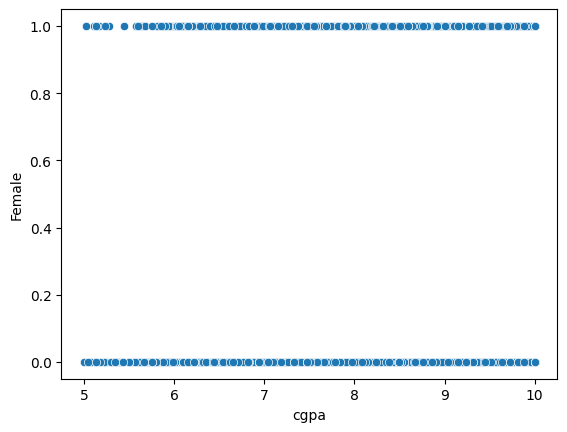

In [69]:
sns.scatterplot(data=x, x='cgpa', y='Female')

In [70]:
# male and female do not really correlate with cgpa, presumably not required, thus we are dropping them

In [71]:
x = x.drop('Male', axis =1)

In [72]:
x = x.drop('Female', axis =1)

In [73]:
x.columns

Index(['branch', 'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
       'study_hours_per_day', 'attendance_percentage', 'projects_completed',
       'internships_completed', 'coding_skill_rating',
       'communication_skill_rating', 'aptitude_skill_rating',
       'hackathons_participated', 'certifications_count', 'sleep_hours',
       'stress_level', 'part_time_job', 'family_income_level', 'city_tier',
       'internet_access', 'extracurricular_involvement'],
      dtype='object')

In [74]:
#lets see what projects_completed has most correlation to

In [75]:
x.corr()['projects_completed'].sort_values()

branch                        -0.175790
backlogs                      -0.068773
internet_access               -0.048785
stress_level                  -0.037149
part_time_job                 -0.016770
extracurricular_involvement   -0.009225
communication_skill_rating    -0.006292
sleep_hours                    0.016089
city_tier                      0.022737
attendance_percentage          0.031709
family_income_level            0.033799
study_hours_per_day            0.046571
internships_completed          0.111052
aptitude_skill_rating          0.130677
twelfth_percentage             0.167963
tenth_percentage               0.189939
cgpa                           0.205021
certifications_count           0.313848
hackathons_participated        0.699562
coding_skill_rating            0.891180
projects_completed             1.000000
Name: projects_completed, dtype: float64

In [76]:
x['coding_skill_rating']

Student_ID
1       4
2       3
3       5
4       3
5       2
       ..
4996    4
4997    4
4998    5
4999    4
5000    5
Name: coding_skill_rating, Length: 5000, dtype: int64

<Axes: xlabel='projects_completed', ylabel='coding_skill_rating'>

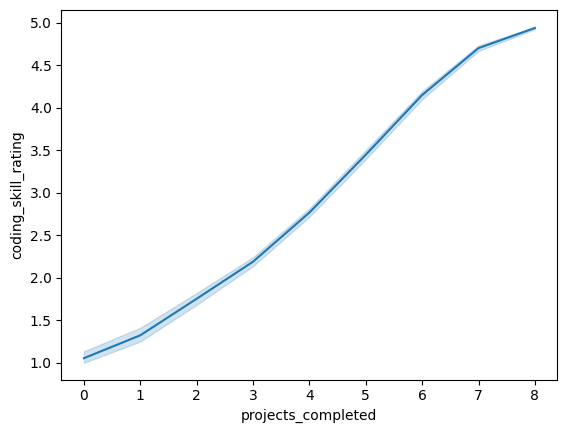

In [77]:
sns.lineplot(data=x, x='projects_completed', y='coding_skill_rating')

In [78]:
#very high correaltion, definately important

<Axes: xlabel='projects_completed', ylabel='hackathons_participated'>

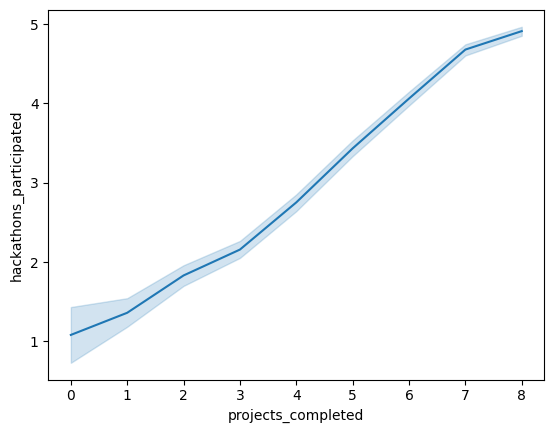

In [79]:
sns.lineplot(data=x, x='projects_completed', y='hackathons_participated')

In [80]:
# again, v.imp

In [81]:
x.corr()['backlogs'].sort_values()

cgpa                          -0.305875
tenth_percentage              -0.278136
twelfth_percentage            -0.268196
aptitude_skill_rating         -0.184201
internships_completed         -0.167554
study_hours_per_day           -0.090390
coding_skill_rating           -0.075287
hackathons_participated       -0.072884
attendance_percentage         -0.069045
projects_completed            -0.068773
sleep_hours                   -0.032800
branch                        -0.024944
certifications_count          -0.014892
part_time_job                 -0.009163
extracurricular_involvement   -0.001201
family_income_level           -0.000843
communication_skill_rating     0.001240
city_tier                      0.010499
stress_level                   0.028096
internet_access                0.038747
backlogs                       1.000000
Name: backlogs, dtype: float64

In [82]:
#backlogs have the most negative relation with cgpa (obviously), we will keep in data

In [83]:
x.corr()['sleep_hours'].sort_values()

stress_level                  -0.161821
backlogs                      -0.032800
branch                        -0.030160
attendance_percentage         -0.013357
study_hours_per_day           -0.010216
internet_access               -0.009071
city_tier                     -0.005272
certifications_count          -0.002494
family_income_level           -0.001146
part_time_job                  0.006764
extracurricular_involvement    0.010328
communication_skill_rating     0.010527
hackathons_participated        0.013016
coding_skill_rating            0.014699
projects_completed             0.016089
tenth_percentage               0.040241
twelfth_percentage             0.046709
aptitude_skill_rating          0.049514
internships_completed          0.051705
cgpa                           0.054210
sleep_hours                    1.000000
Name: sleep_hours, dtype: float64

<Axes: xlabel='sleep_hours', ylabel='stress_level'>

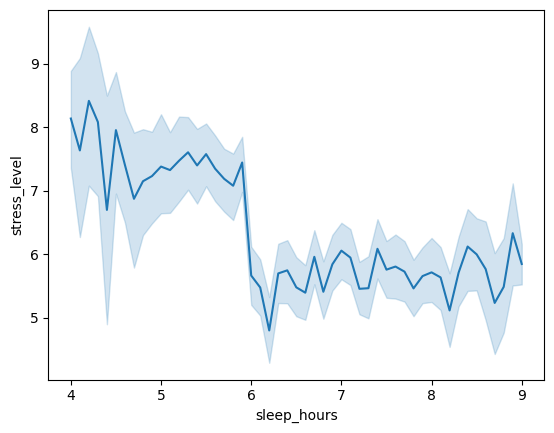

In [84]:
sns.lineplot(data = x, x = 'sleep_hours', y='stress_level')

In [85]:
#definitely a factor

In [86]:
#checking the labels once

In [87]:
y

,placement_status,salary_lpa
Student_ID,,
1,Placed,14.95
2,Placed,14.91
3,Placed,17.73
4,Placed,14.52
5,Placed,15.91
...,...,...
4996,Placed,19.35
4997,Not Placed,0.00
4998,Placed,19.13


In [88]:
y_class

Student_ID
1           Placed
2           Placed
3           Placed
4           Placed
5           Placed
           ...    
4996        Placed
4997    Not Placed
4998        Placed
4999        Placed
5000        Placed
Name: placement_status, Length: 5000, dtype: object

<Axes: xlabel='placement_status', ylabel='count'>

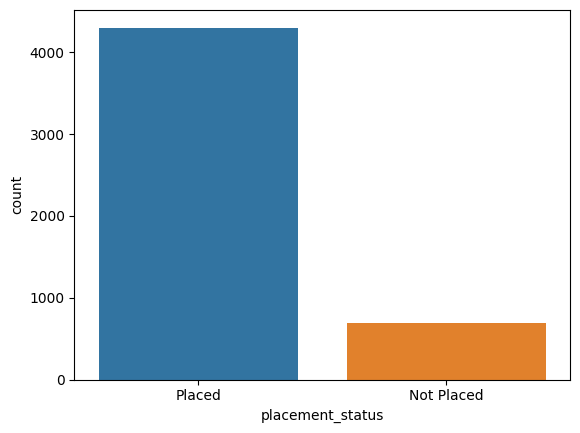

In [89]:
sns.countplot(data = y, x = 'placement_status', hue='placement_status')

In [90]:
#unbalanced data

In [91]:
#cgpa and salary relation

<Axes: xlabel='cgpa', ylabel='salary_lpa'>

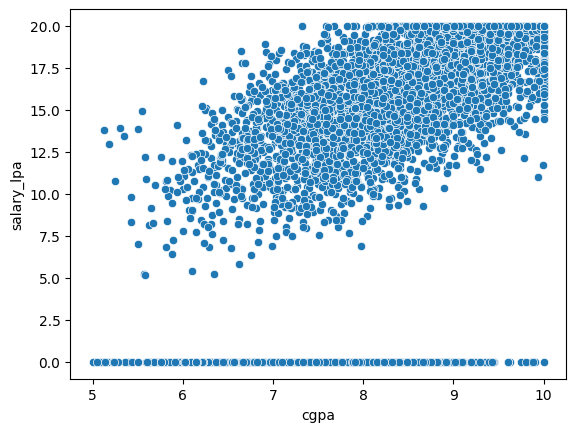

In [92]:
sns.scatterplot(data = y, x=x['cgpa'], y = y['salary_lpa'])

In [93]:
#very sparse relation ship
#making 2 models after train_test_split and scaling

In [94]:
x.shape

(5000, 21)

In [95]:
from sklearn.model_selection import train_test_split

In [96]:
xtr , xts, ytr, yts = train_test_split(x,coded_y_class, test_size = 0.2)

In [97]:
xtr.shape

(4000, 21)

In [98]:
xts.shape

(1000, 21)

In [99]:
from sklearn.preprocessing import MinMaxScaler  #because there are no values below zero

In [100]:
scaler= MinMaxScaler()
xtr_scaled = scaler.fit_transform(xtr)
xts_scaled = scaler.transform(xts)

In [101]:
xtr_scaled.shape

(4000, 21)

In [102]:
ytr

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(4000, 1))

In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

C:\Users\Abhishek\tf-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [104]:
classifier = Sequential()

classifier.add(Input([21]))
classifier.add(Dense(52, activation='relu'))
classifier.add(Dense(128, activation='relu'))
classifier.add(Dense(256, activation='relu'))


classifier.add(Dense(1, activation='sigmoid')) #as it is binary classification of pass or not

classifier.compile(loss ='binary_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [105]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 52)                  │           1,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           6,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,209 (160.97 KB)

 Trainable params: 41,209 (160.97 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
from tensorflow.keras.callbacks import EarlyStopping

In [107]:
early_stop = EarlyStopping(patience = 20, mode = 'min')

In [108]:
classifier.fit(xtr_scaled, ytr, validation_data = (xts,yts), epochs = 2000, callbacks = [early_stop])

Epoch 1/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8662 - loss: 0.3322 - val_accuracy: 0.8600 - val_loss: 11.4734
Epoch 2/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8865 - loss: 0.2618 - val_accuracy: 0.8600 - val_loss: 10.8850
Epoch 3/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8895 - loss: 0.2501 - val_accuracy: 0.8600 - val_loss: 7.3448
Epoch 4/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8892 - loss: 0.2426 - val_accuracy: 0.8600 - val_loss: 8.5518
Epoch 5/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8915 - loss: 0.2391 - val_accuracy: 0.8600 - val_loss: 7.5687
Epoch 6/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8928 - loss: 0.2405 - val_accuracy: 0.8600 - val_loss: 6.4481
Epoch 7/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8947 - loss: 0.2347 - val_accuracy: 0.8600 - val_loss: 11.7854
Epoch 8/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8967 - loss: 0.2332

In [163]:
metrics = pd.DataFrame(classifier.history.history)

In [110]:
metrics.head()

,accuracy,loss,val_accuracy,val_loss
0,0.86625,0.332196,0.86,11.473367
1,0.88650,0.261847,0.86,10.885026
2,0.88950,0.250069,0.86,7.344790
3,0.88925,0.242648,0.86,8.551824
4,0.89150,0.239070,0.86,7.568656


<Axes: >

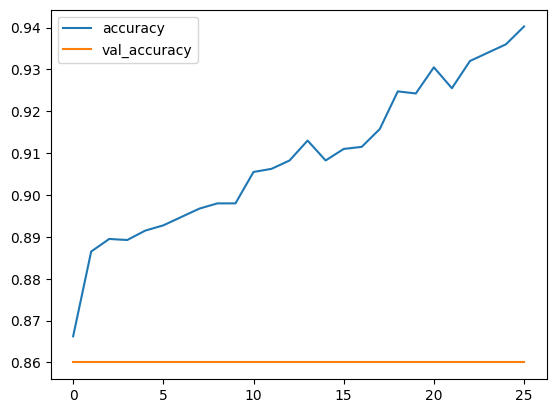

In [111]:
metrics[['accuracy', 'val_accuracy']].plot()

<Axes: >

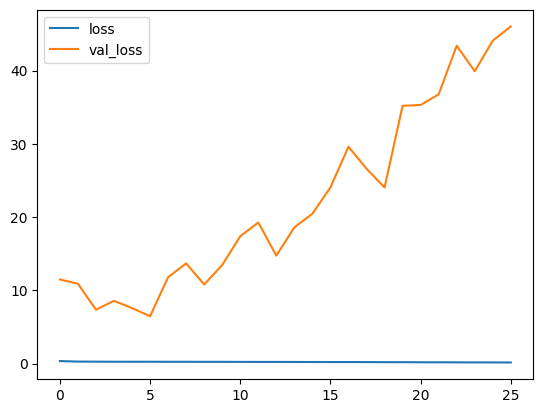

In [112]:
metrics[['loss', 'val_loss']].plot()

In [113]:
classifier.evaluate(xts,yts)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8600 - loss: 46.0135 


[46.013526916503906, 0.8600000143051147]

In [114]:
#86 % val accuracy

In [115]:
from sklearn.metrics import classification_report, confusion_matrix

In [116]:
pred = classifier.predict(xts)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [117]:
pred = (pred>0.7).astype('int32')

<Axes: >

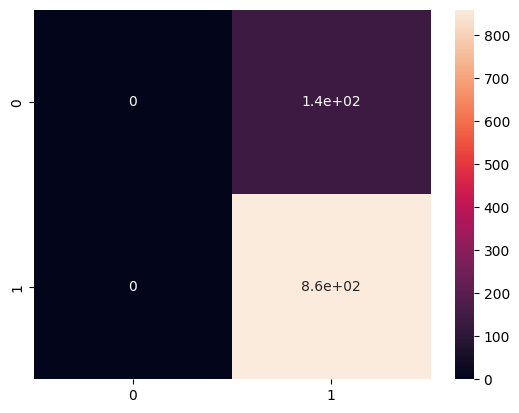

In [118]:
sns.heatmap(confusion_matrix(yts,pred), annot = True)

In [119]:
#this is because my labels are heavily skewed for passed

<Axes: xlabel='placement_status', ylabel='count'>

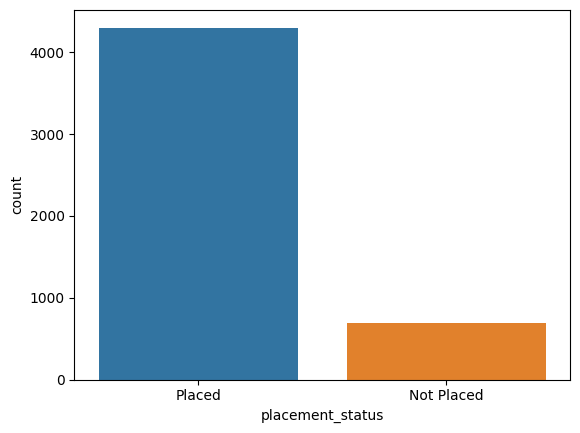

In [120]:
sns.countplot(data = y, x = 'placement_status', hue='placement_status')

In [121]:
#what if i cutdown my training data, to include even number of y labels?

In [122]:
y_class.value_counts()

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

In [123]:
(697/5000)*100

13.94

In [124]:
#only 13.94% are not cleared

In [125]:
placed_y = y_class[y_class == 'Placed']
placed_y

Student_ID
1       Placed
2       Placed
3       Placed
4       Placed
5       Placed
         ...  
4995    Placed
4996    Placed
4998    Placed
4999    Placed
5000    Placed
Name: placement_status, Length: 4303, dtype: object

In [126]:
small_y_placed = placed_y[:697]

In [127]:
not_placed_y = y_class[y_class == 'Not Placed']

In [128]:
new_y_class = pd.concat([small_y_placed, not_placed_y], axis=0)

In [129]:
new_y_class.value_counts()

placement_status
Placed        697
Not Placed    697
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='placement_status'>

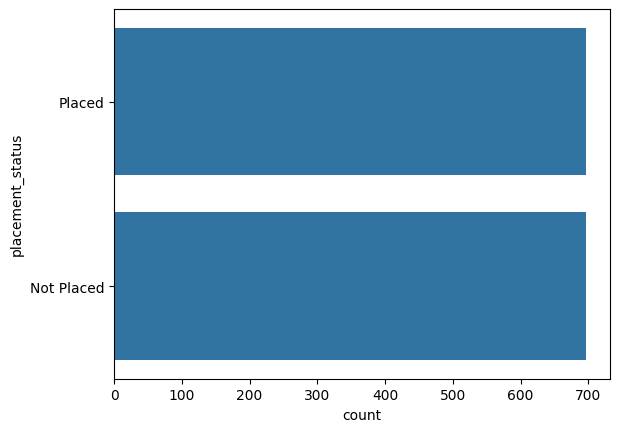

In [130]:
sns.countplot(data=new_y_class)

In [136]:
#now at same level, finding x corresponding to these new labels

In [137]:
new_y_class.index

Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
       ...
       4966, 4967, 4973, 4978, 4982, 4984, 4985, 4987, 4989, 4997],
      dtype='int64', name='Student_ID', length=1394)

In [138]:
x.index

Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
       ...
       4991, 4992, 4993, 4994, 4995, 4996, 4997, 4998, 4999, 5000],
      dtype='int64', name='Student_ID', length=5000)

In [139]:
new_class_df = pd.concat([x,new_y_class], axis =1, join='inner' )

In [146]:
new_class_df.index

Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
       ...
       4966, 4967, 4973, 4978, 4982, 4984, 4985, 4987, 4989, 4997],
      dtype='int64', name='Student_ID', length=1394)

In [149]:
new_class_df.columns

Index(['branch', 'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
       'study_hours_per_day', 'attendance_percentage', 'projects_completed',
       'internships_completed', 'coding_skill_rating',
       'communication_skill_rating', 'aptitude_skill_rating',
       'hackathons_participated', 'certifications_count', 'sleep_hours',
       'stress_level', 'part_time_job', 'family_income_level', 'city_tier',
       'internet_access', 'extracurricular_involvement', 'placement_status'],
      dtype='object')

In [135]:
new_y_encoder = LabelBinarizer()

In [147]:
y_class_encoded = new_y_encoder.fit_transform(new_y_class)

In [150]:
new_x_class = new_class_df.drop('placement_status', axis = 1)

In [214]:
xtr , xts, ytr, yts = train_test_split(new_x_class,y_class_encoded, test_size = 0.3)

In [215]:
new_scaler = MinMaxScaler()

In [216]:
scaled_xtr = new_scaler.fit_transform(xtr)

In [217]:
scaled_xts = new_scaler.transform(xts)

In [248]:
scaled_xtr.shape

(975, 21)

In [249]:
scaled_xts.shape

(419, 21)

In [411]:
classifier = Sequential()

classifier.add(Input([21]))
#classifier.add(Dense(64, activation='relu'))
classifier.add(Dense(32, activation='relu'))
classifier.add(Dropout(0.2))
classifier.add(Dense(16, activation='relu'))
classifier.add(Dropout(0.2))
classifier.add(Dense(1, activation='sigmoid')) #as it is binary classification of pass or not

classifier.compile(loss ='binary_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [412]:
classifier.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_114 (Dense)                    │ (None, 32)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_115 (Dense)                    │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_116 (Dense)                    │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

In [448]:
early_stop = EarlyStopping(monitor = 'val_accuracy',patience = 20, mode = 'max', restore_best_weights=True)

In [414]:
classifier.fit(scaled_xtr, ytr, validation_data = (scaled_xts,yts), epochs = 2000, callbacks = [early_stop])

Epoch 1/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5169 - loss: 0.6972 - val_accuracy: 0.6277 - val_loss: 0.6693
Epoch 2/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5938 - loss: 0.6721 - val_accuracy: 0.6539 - val_loss: 0.6543
Epoch 3/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6092 - loss: 0.6628 - val_accuracy: 0.6778 - val_loss: 0.6432
Epoch 4/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6174 - loss: 0.6457 - val_accuracy: 0.6683 - val_loss: 0.6328
Epoch 5/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6400 - loss: 0.6445 - val_accuracy: 0.6802 - val_loss: 0.6261
Epoch 6/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6759 - loss: 0.6225 - val_accuracy: 0.6826 - val_loss: 0.6176
Epoch 7/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6503 - loss: 0.6228 - val_accuracy: 0.6874 - val_loss: 0.6117
Epoch 8/2000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6636 - loss: 0.6131 - val_accuracy: 0.

In [415]:
metrics = pd.DataFrame(classifier.history.history)

<Axes: >

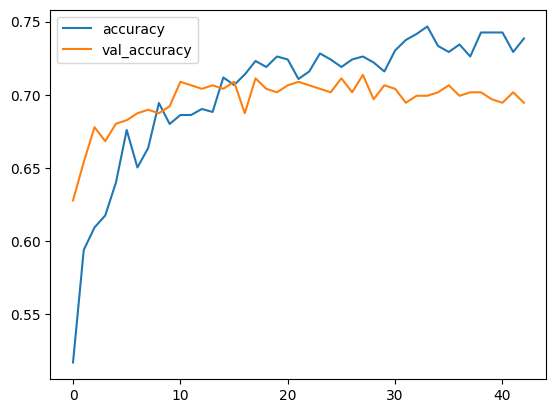

In [416]:
metrics[['accuracy', 'val_accuracy']].plot()

<Axes: >

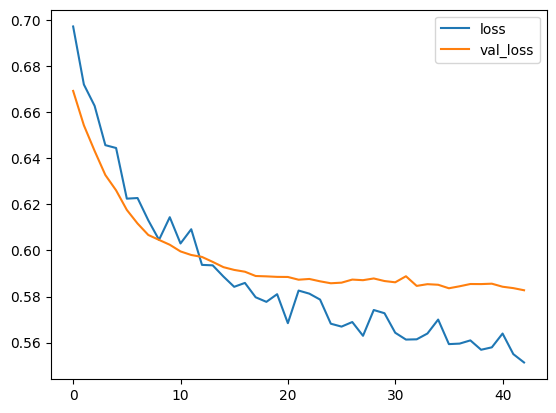

In [417]:
metrics[['loss', 'val_loss']].plot()

In [418]:
classifier.evaluate(scaled_xts, yts)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7136 - loss: 0.5871 


[0.5870950222015381, 0.7136037945747375]

In [419]:
pred = classifier.predict(xts)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [421]:
pred = (pred>0.7).astype('int32')

<Axes: >

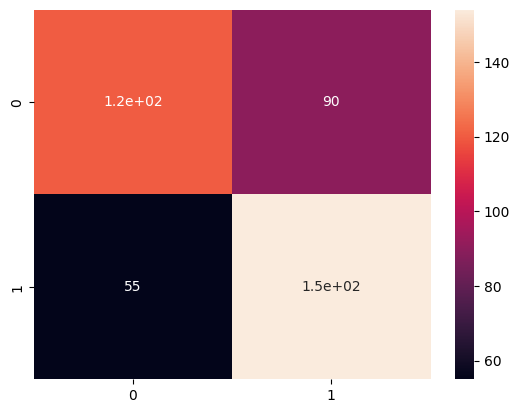

In [422]:
sns.heatmap(confusion_matrix(yts,pred), annot = True)

In [423]:
print(classification_report(yts, pred))

              precision    recall  f1-score   support

           0       0.69      0.57      0.62       210
           1       0.63      0.74      0.68       209

    accuracy                           0.65       419
   macro avg       0.66      0.65      0.65       419
weighted avg       0.66      0.65      0.65       419



In [426]:
# now comparing to a forest ml model, which helps to compare

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(scaled_xtr, ytr.ravel())
print(classification_report(yts, rf.predict(scaled_xts)))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71       210
           1       0.71      0.67      0.69       209

    accuracy                           0.70       419
   macro avg       0.70      0.70      0.70       419
weighted avg       0.70      0.70      0.70       419



In [432]:
# therefore our NN classifier cannot be improved futher, as it is very closed to tuned
# now, we will forgo the train test split and train on full balanced data with current neural architecture

In [433]:
full_scaler = MinMaxScaler()

full_x_scaled = full_scaler.fit_transform(new_x_class)

In [434]:
import joblib

In [437]:
joblib.dump(full_x_scaled,'project_1_scaler.pkl')

['project_1_scaler.pkl']

In [439]:
full_x_scaled.shape

(1394, 21)

In [441]:
y_class_encoded.shape

(1394, 1)

In [478]:
classifier = Sequential()

classifier.add(Input([21]))
#classifier.add(Dense(64, activation='relu'))
classifier.add(Dense(32, activation='relu'))
classifier.add(Dropout(0.2))
classifier.add(Dense(16, activation='relu'))
classifier.add(Dropout(0.2))
classifier.add(Dense(1, activation='sigmoid')) #as it is binary classification of pass or not

classifier.compile(loss ='binary_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [479]:
classifier.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_123 (Dense)                    │ (None, 32)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_124 (Dense)                    │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_125 (Dense)                    │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

In [480]:
early_stop = EarlyStopping(monitor= 'accuracy' , mode = 'max', patience = 20, restore_best_weights=True)

In [481]:
classifier.fit(full_x_scaled, y_class_encoded, epochs = 2000, callbacks = [early_stop])

Epoch 1/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5488 - loss: 0.6896   
Epoch 2/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5746 - loss: 0.6734 
Epoch 3/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6004 - loss: 0.6673
Epoch 4/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6334 - loss: 0.6500
Epoch 5/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6392 - loss: 0.6379 
Epoch 6/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6528 - loss: 0.6329 
Epoch 7/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6471 - loss: 0.6277 
Epoch 8/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6714 - loss: 0.6143 
Epoch 9/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6707 - loss: 0.6133 
Epoch 10/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6829 - loss: 0.6018 
Epoch 11/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6829 - loss: 0.6073 
Epoch 12/2000
44/44 ━━━━━━━━━━━━━━━━━━━━ 

In [482]:
metrics = pd.DataFrame(classifier.history.history)

<Axes: >

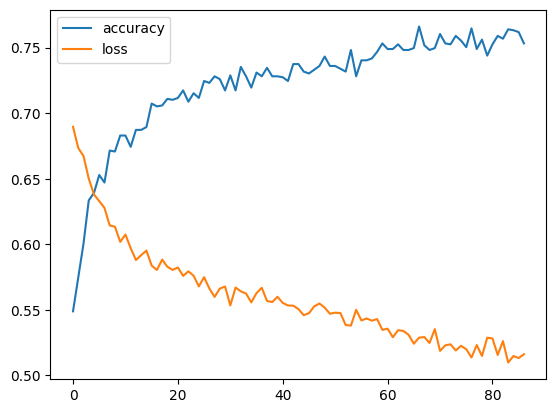

In [483]:
metrics[['accuracy', 'loss']].plot()

In [495]:
pred = classifier.predict(full_x_scaled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step


In [496]:
pred = (pred>0.45).astype('int32')

<Axes: >

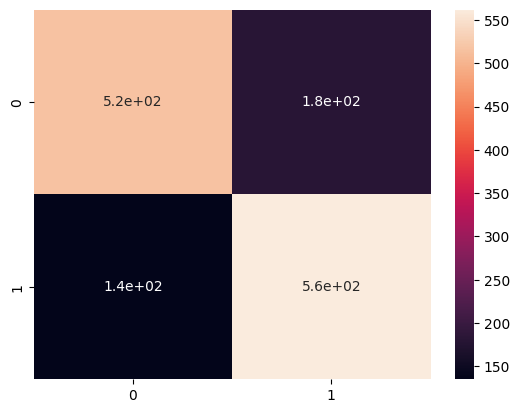

In [497]:
sns.heatmap(confusion_matrix(y_class_encoded,pred), annot = True)

In [498]:
print(classification_report(y_class_encoded, pred))

              precision    recall  f1-score   support

           0       0.79      0.74      0.77       697
           1       0.76      0.81      0.78       697

    accuracy                           0.77      1394
   macro avg       0.77      0.77      0.77      1394
weighted avg       0.77      0.77      0.77      1394



In [500]:
classifier.save('project1_classifier.keras')

In [428]:
# beginning regression

In [429]:
y_reg

Student_ID
1       14.95
2       14.91
3       17.73
4       14.52
5       15.91
        ...  
4996    19.35
4997     0.00
4998    19.13
4999    16.53
5000    20.00
Name: salary_lpa, Length: 5000, dtype: float64

In [501]:
x.shape

(5000, 21)

In [503]:
# adding the placement status seems to be crucial for the training data, as it directly correlates to salary lpa

In [507]:
coded_y_class.shape

(5000, 1)

In [511]:
new_reg_df = pd.concat([x, y_class], axis = 1)

In [512]:
new_reg_df

,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status
Student_ID,,,,,,,,,,,,,,,,,,,,,
1,2,8.74,74.0,75.0,0,3.8,71.1,7,3,4,...,4,5,6.5,8,1,1,2,1,2,Placed
2,2,7.80,75.3,69.7,0,6.3,69.5,5,1,3,...,4,1,7.1,8,1,1,3,1,1,Placed
3,1,6.95,62.8,68.3,0,1.5,62.5,8,2,5,...,6,3,6.1,2,0,0,2,1,3,Placed
4,2,7.46,57.9,51.4,1,4.7,64.6,6,2,3,...,2,2,7.3,7,0,1,1,1,1,Placed
5,1,6.86,61.3,73.5,2,5.2,75.9,3,3,2,...,2,1,6.0,7,0,1,1,1,2,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,1,10.00,90.4,98.3,0,3.7,75.3,6,3,4,...,4,2,7.3,2,0,1,3,1,1,Placed
4997,1,7.76,74.3,72.6,2,6.3,72.3,4,4,4,...,3,2,7.8,6,0,0,1,1,1,Not Placed
4998,1,7.79,64.0,71.2,2,2.0,63.8,6,1,5,...,6,2,6.1,5,1,0,2,2,2,Placed


In [520]:
new_label = {1:'Placed',
            0:"Not Placed"}
new_reg_df['placement_status']=new_reg_df['placement_status'].replace(new_label)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_25548\2753559456.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_reg_df['placement_status']=new_reg_df['placement_status'].replace(new_label)


In [518]:
label_encoder.get_params()

{'neg_label': 0, 'pos_label': 1, 'sparse_output': False}

In [523]:
new_reg_df[20:40]

,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status
Student_ID,,,,,,,,,,,,,,,,,,,,,
21,4,7.22,70.4,67.8,1,3.1,62.8,3,1,3,...,2,3,6.9,2,1,0,1,1,3,0
22,2,7.75,70.7,70.9,2,6.4,91.2,3,2,2,...,1,1,5.8,10,0,0,3,1,1,0
23,1,7.60,77.7,64.1,0,4.8,72.0,8,2,5,...,3,2,7.2,7,0,2,1,1,1,1
24,3,7.56,70.3,67.0,0,2.4,70.3,7,3,5,...,5,6,6.9,10,0,0,3,1,2,1
25,1,8.59,84.4,82.7,0,5.2,76.3,5,3,4,...,4,5,6.9,8,0,1,1,1,2,1
26,2,7.57,70.3,62.5,2,3.8,72.2,6,1,4,...,4,1,6.7,3,0,0,3,1,1,0
27,0,7.37,71.9,62.6,0,5.0,79.4,4,0,2,...,2,2,4.5,10,0,2,2,1,1,1
28,0,7.91,71.3,71.1,0,1.6,70.2,2,1,2,...,3,5,8.5,2,0,2,2,1,2,1
29,3,8.98,87.1,80.5,0,3.5,62.6,7,3,5,...,5,3,6.9,10,1,1,2,1,1,1


In [527]:
new_reg_df.corr()['placement_status'].sort_values()

backlogs                      -0.415297
branch                        -0.127696
internet_access               -0.053741
stress_level                  -0.045556
extracurricular_involvement   -0.018528
city_tier                     -0.002014
family_income_level            0.001803
part_time_job                  0.006404
sleep_hours                    0.016469
attendance_percentage          0.042426
study_hours_per_day            0.065022
communication_skill_rating     0.074704
certifications_count           0.125657
aptitude_skill_rating          0.213778
internships_completed          0.254189
twelfth_percentage             0.268454
tenth_percentage               0.269680
hackathons_participated        0.275848
cgpa                           0.315614
projects_completed             0.322796
coding_skill_rating            0.343219
placement_status               1.000000
Name: placement_status, dtype: float64

In [528]:
xtr, xts, ytr, yts = train_test_split(new_reg_df, y_reg, test_size = 0.2)

In [534]:
xtr.head()

,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status
Student_ID,,,,,,,,,,,,,,,,,,,,,
2648,0,7.58,60.3,69.5,0,2.7,69.6,2,1,3,...,3,1,6.9,5,1,0,3,1,0,1
1446,2,8.84,83.1,73.0,0,6.1,74.5,6,3,3,...,2,3,5.9,10,0,2,3,1,0,1
4823,4,8.49,83.7,77.4,2,0.0,65.9,7,3,5,...,5,2,6.6,7,0,1,3,1,2,1
2775,2,7.67,73.6,61.6,0,5.6,79.4,6,0,4,...,5,4,6.1,7,0,1,3,1,3,1
2495,1,9.02,78.3,77.7,1,5.1,75.1,5,2,3,...,2,1,7.2,7,1,0,1,1,0,1


In [530]:
xtr.shape

(4000, 22)

In [531]:
reg_scaler = MinMaxScaler()
scaled_xtr = reg_scaler.fit_transform(xtr)
scaled_xts = reg_scaler.transform(xts)

In [546]:
regressor = Sequential()

regressor.add(Input([22,]))
regressor.add(Dense(64, activation = 'relu'))
regressor.add(Dropout(0.3))
regressor.add(Dense(32, activation = 'relu'))
regressor.add(Dropout(0.3))
regressor.add(Dense(16, activation = 'relu'))

regressor.add(Dense(1, activation = 'linear'))

regressor.compile(loss = 'mse', optimizer = 'adam')

In [547]:
regressor.summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_130 (Dense)                    │ (None, 64)                  │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_131 (Dense)                    │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_132 (Dense)                    │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_133 (Dense)                    │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [548]:
early_stop = EarlyStopping(monitor='loss', mode = 'min', patience = 15, restore_best_weights=True)

In [549]:
regressor.fit(scaled_xtr, ytr, epochs = 2000, validation_data=(scaled_xts, yts), callbacks=[early_stop])

Epoch 1/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 87.4184 - val_loss: 16.7251
Epoch 2/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.8440 - val_loss: 5.6830
Epoch 3/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.9491 - val_loss: 3.3911
Epoch 4/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.7259 - val_loss: 3.5865
Epoch 5/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.7256 - val_loss: 3.5638
Epoch 6/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1578 - val_loss: 5.5290
Epoch 7/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6461 - val_loss: 4.7118
Epoch 8/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0912 - val_loss: 6.6066
Epoch 9/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5930 - val_loss: 4.9974
Epoch 10/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6000 - val_loss: 6.8152
Epoch 11/2000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1293 - val_loss: 10.2531
Epoch 12/2000
125/125 ━━━

In [550]:
metrics = pd.DataFrame(regressor.history.history)

<Axes: >

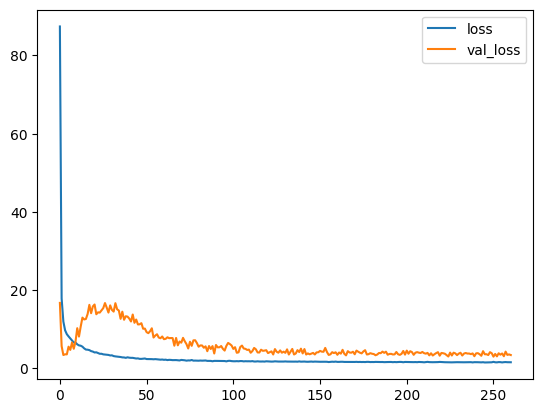

In [551]:
metrics.plot()

In [554]:
regressor.evaluate(scaled_xts, yts)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5906 


3.5906119346618652

In [555]:
pred = regressor.predict(scaled_xts)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [560]:
pred[:10]

array([[1.8000722e-02],
       [1.4588201e+01],
       [1.3089479e+01],
       [1.5237038e+01],
       [1.7064558e+01],
       [1.7761837e+01],
       [1.6894987e+01],
       [1.7583370e-04],
       [1.4825616e+01],
       [1.7636902e+01]], dtype=float32)

In [557]:
yts[:10]

Student_ID
1172     0.00
1122    15.09
1007    12.82
1725    15.53
3089    20.00
2785    20.00
656     18.74
2214     0.00
4223    17.31
3925    19.97
Name: salary_lpa, dtype: float64

In [561]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [562]:
rmse = root_mean_squared_error(yts, pred)

In [563]:
mae = mean_absolute_error(yts, pred)

In [564]:
print(rmse, mae)

1.8948908950479662 1.4965113093948361


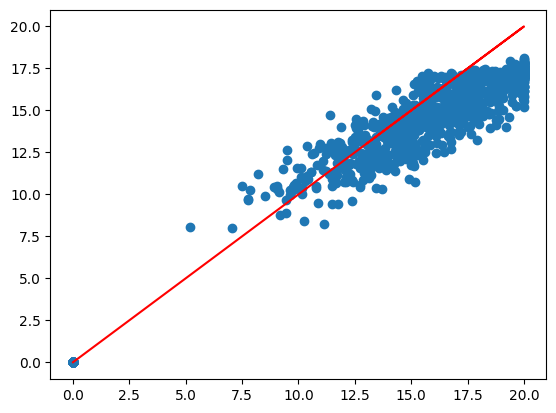

In [566]:
plt.scatter(yts, pred)
plt.plot(yts,yts, c='r')

In [567]:
# this model is very good, now training for full dataset

In [568]:
full_reg_scaler = MinMaxScaler()

In [569]:
scaled_reg_df = full_reg_scaler.fit_transform(new_reg_df)

In [570]:
y_reg.shape

(5000,)

In [572]:
scaled_reg_df.shape

(5000, 22)

In [576]:
regressor = Sequential()

regressor.add(Input([22,]))
regressor.add(Dense(64, activation = 'relu'))
regressor.add(Dropout(0.3))
regressor.add(Dense(32, activation = 'relu'))
regressor.add(Dropout(0.3))
regressor.add(Dense(16, activation = 'relu'))

regressor.add(Dense(1, activation = 'linear'))

regressor.compile(loss = 'mse', optimizer = 'adam')

In [577]:
regressor.summary()

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_138 (Dense)                    │ (None, 64)                  │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_139 (Dense)                    │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_140 (Dense)                    │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_141 (Dense)                    │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [579]:
regressor.fit(scaled_reg_df, y_reg, epochs = 261)

Epoch 1/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 67.7118 
Epoch 2/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.8405
Epoch 3/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.7953
Epoch 4/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.6893   
Epoch 5/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.6150
Epoch 6/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.6801
Epoch 7/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.3279
Epoch 8/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.3146
Epoch 9/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7851  
Epoch 10/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1785  
Epoch 11/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1718  
Epoch 12/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6195
Epoch 13/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.5495
Epoch 14/261
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.1536  
Epoch 15/261
157/157 ━━━━━━━

In [580]:
loss = pd.DataFrame(regressor.history.history)

In [582]:
loss.head()

,loss
0,67.711838
1,15.840495
2,10.795306
3,9.689347
4,8.614957


<Axes: >

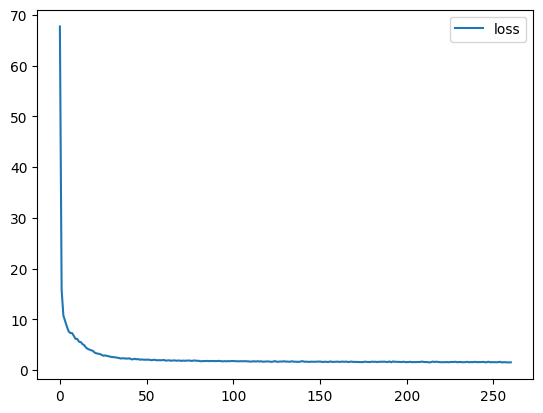

In [583]:
loss.plot()

In [584]:
pred = regressor.predict(scaled_reg_df[2000:4000])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [586]:
rmse = root_mean_squared_error(y_reg[2000:4000], pred)

In [587]:
mae = mean_absolute_error(y_reg[2000:4000], pred)

In [588]:
print(rmse, mae)

1.6452760373177944 1.2854455772113802
